In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
import joblib
import os
import warnings

warnings.filterwarnings('ignore')

# Load dataset mentah
df = pd.read_csv('data/hotel_reviews_dataset.csv')

print(f"✅ Dataset dimuat: {df.shape[0]} baris x {df.shape[1]} kolom")
df.head()


✅ Dataset dimuat: 4933 baris x 11 kolom


,platform,overall_score,cleanliness,comfort,location,service,facility,value_for_money,meal,free_wifi,amenities
0,Traveloka,9.4,9.3,8.9,9.0,9.2,9.6,NaN,8.8,NaN,NaN
1,Traveloka,9.1,9.2,9.1,9.1,9.3,9.3,NaN,8.5,NaN,NaN
2,Traveloka,9.4,9.4,9.2,9.6,9.4,9.5,NaN,8.5,NaN,NaN
3,Traveloka,9.2,9.7,9.6,9.5,9.0,8.7,NaN,8.9,NaN,NaN
4,Traveloka,8.7,9.1,8.8,9.2,8.9,8.7,NaN,8.4,NaN,NaN


In [3]:
# Drop kolom yang NaN > 70% dan korelasi hampir nol
cols_to_drop = ['meal', 'free_wifi', 'amenities', 'comfort']

df_clean = df.drop(columns=cols_to_drop)

print("✅ Kolom yang di-drop:")
for col in cols_to_drop:
    nan_pct = df[col].isnull().sum() / len(df) * 100
    print(f"   - {col:15s}: NaN {nan_pct:.1f}%")

print(f"\nShape setelah drop: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")
print(f"Kolom tersisa: {list(df_clean.columns)}")

✅ Kolom yang di-drop:
   - meal           : NaN 83.1%
   - free_wifi      : NaN 91.9%
   - amenities      : NaN 89.5%
   - comfort        : NaN 75.0%

Shape setelah drop: 4933 baris x 7 kolom
Kolom tersisa: ['platform', 'overall_score', 'cleanliness', 'location', 'service', 'facility', 'value_for_money']


In [4]:
duplicate_count = df_clean.duplicated().sum()
duplicate_pct = duplicate_count / len(df) * 100

print("Jumlah data duplikat:", duplicate_count)
print("Persentase data duplikat:", round(duplicate_pct, 2), "%")

Jumlah data duplikat: 29
Persentase data duplikat: 0.59 %


In [5]:
# Tambah indicator variables SEBELUM imputasi
# Tujuannya agar informasi nilai yang awalnya kosong tetap tersimpan setelah imputasi

df_clean['is_facility_available'] = df_clean['facility'].notnull().astype(int)
df_clean['is_value_for_money_available'] = df_clean['value_for_money'].notnull().astype(int)

print("✅ Indicator variables ditambahkan:")
print(f"\n   is_facility_available:")
print(df_clean['is_facility_available'].value_counts().sort_index(ascending=False).to_string())

print(f"\n   is_value_for_money_available:")
print(df_clean['is_value_for_money_available'].value_counts().sort_index(ascending=False).to_string())

print(f"\nShape sekarang: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")


✅ Indicator variables ditambahkan:

   is_facility_available:
is_facility_available
1    4413
0     520

   is_value_for_money_available:
is_value_for_money_available
1    3580
0    1353

Shape sekarang: 4933 baris x 9 kolom


In [ ]:
# Penanganan missing values menggunakan KNN Imputer

cols_to_impute = ['facility', 'value_for_money']

print("Sebelum imputasi:")
for col in cols_to_impute:
    print(f"   {col:20s}: {df_clean[col].isnull().sum()} NaN")

sample_missing_before = df_clean[
    df_clean[cols_to_impute].isnull().any(axis=1)
][['platform', 'cleanliness', 'location', 'service', 'facility', 'value_for_money']].head(5).copy()

imputer = KNNImputer(n_neighbors=5)

numeric_cols_for_impute = [
    'cleanliness',
    'location',
    'service',
    'facility',
    'value_for_money'
]

df_clean[numeric_cols_for_impute] = imputer.fit_transform(
    df_clean[numeric_cols_for_impute]
)

for col in cols_to_impute:
    df_clean[col] = df_clean[col].round(1)

sample_missing_after = df_clean.loc[
    sample_missing_before.index,
    ['platform', 'cleanliness', 'location', 'service', 'facility', 'value_for_money']
].copy()

print("\nSetelah imputasi:")
for col in cols_to_impute:
    print(f"   {col:20s}: {df_clean[col].isnull().sum()} NaN ✅")

print(f"\nShape: {df_clean.shape}")

print("\nContoh sebelum imputasi:")
display(sample_missing_before)

print("\nContoh sesudah imputasi:")
display(sample_missing_after)


Sebelum imputasi:
   facility            : 520 NaN
   value_for_money     : 1353 NaN

Setelah imputasi:
   facility            : 0 NaN ✅
   value_for_money     : 0 NaN ✅

Shape: (4933, 9)

Contoh sebelum imputasi:


,platform,cleanliness,location,service,facility,value_for_money
0,Traveloka,9.3,9.0,9.2,9.6,NaN
1,Traveloka,9.2,9.1,9.3,9.3,NaN
2,Traveloka,9.4,9.6,9.4,9.5,NaN
3,Traveloka,9.7,9.5,9.0,8.7,NaN
4,Traveloka,9.1,9.2,8.9,8.7,NaN



Contoh sesudah imputasi:


,platform,cleanliness,location,service,facility,value_for_money
0,Traveloka,9.3,9.0,9.2,9.6,9.2
1,Traveloka,9.2,9.1,9.3,9.3,9.3
2,Traveloka,9.4,9.6,9.4,9.5,9.1
3,Traveloka,9.7,9.5,9.0,8.7,8.9
4,Traveloka,9.1,9.2,8.9,8.7,9.0


In [ ]:
# Simpan platform asli untuk stratifikasi split dan kebutuhan analisis
platform_stratify = df_clean['platform'].copy()

df_encoded = pd.get_dummies(df_clean, columns=['platform'], prefix='platform')

platform_cols = [col for col in df_encoded.columns if col.startswith('platform_')]
df_encoded[platform_cols] = df_encoded[platform_cols].astype(int)

print("✅ One-Hot Encoding selesai")
print(f"\nKolom platform yang dibuat:")
for col in platform_cols:
    print(f"   {col}: {df_encoded[col].sum()} baris bernilai 1")

print(f"\nShape sekarang: {df_encoded.shape[0]} baris x {df_encoded.shape[1]} kolom")
print(f"\nSemua kolom:\n{list(df_encoded.columns)}")


✅ One-Hot Encoding selesai

Kolom platform yang dibuat:
   platform_Agoda: 2245 baris bernilai 1
   platform_Booking.com: 401 baris bernilai 1
   platform_Tiket.com: 934 baris bernilai 1
   platform_Traveloka: 833 baris bernilai 1
   platform_Trip.com: 520 baris bernilai 1

Shape sekarang: 4933 baris x 13 kolom

Semua kolom:
['overall_score', 'cleanliness', 'location', 'service', 'facility', 'value_for_money', 'is_facility_available', 'is_value_for_money_available', 'platform_Agoda', 'platform_Booking.com', 'platform_Tiket.com', 'platform_Traveloka', 'platform_Trip.com']


In [ ]:
# Scaling
cols_to_scale = [
    'cleanliness',
    'location',
    'service',
    'facility',
    'value_for_money'
]

df_encoded['overall_score_raw'] = df_encoded['overall_score'].copy()

print("✅ overall_score_raw tersimpan")
print("   Scaling akan dilakukan setelah split")
print(f"   Kolom yang akan di-scale: {cols_to_scale}")


✅ overall_score_raw tersimpan
   Scaling akan dilakukan setelah split
   Kolom yang akan di-scale: ['cleanliness', 'location', 'service', 'facility', 'value_for_money']


In [ ]:
# Kolom fitur (X)
feature_cols = [
    'cleanliness',
    'location',
    'service',
    'facility',
    'value_for_money',
    'is_facility_available',
    'is_value_for_money_available'
] + platform_cols

X = df_encoded[feature_cols].copy()
y_reg = df_encoded['overall_score_raw'].copy()

print("✅ X dan y berhasil dipisahkan")
print(f"\nShape X     : {X.shape}")
print(f"Shape y_reg : {y_reg.shape}")

print(f"\nFitur yang digunakan ({len(feature_cols)}):")
for col in feature_cols:
    print(f"   - {col}")

print(f"\nTarget regresi: overall_score_raw")


✅ X dan y berhasil dipisahkan

Shape X     : (4933, 12)
Shape y_reg : (4933,)

Fitur yang digunakan (12):
   - cleanliness
   - location
   - service
   - facility
   - value_for_money
   - is_facility_available
   - is_value_for_money_available
   - platform_Agoda
   - platform_Booking.com
   - platform_Tiket.com
   - platform_Traveloka
   - platform_Trip.com

Target regresi: overall_score_raw


In [ ]:
# Stratifikasi berdasarkan platform agar distribusi platform pada train dan test tetap seimbang

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42,
    stratify=platform_stratify
)

print("✅ Train-Test Split selesai (80:20)")
print(f"   Train: {len(X_train_reg):,} data")
print(f"   Test : {len(X_test_reg):,} data")

def platform_distribution(X_data, name):
    print(f"\nDistribusi platform pada {name}:")
    for col in platform_cols:
        count = int(X_data[col].sum())
        pct = count / len(X_data) * 100
        print(f"   {col.replace('platform_', ''):12s}: {count:5d} data ({pct:5.1f}%)")

platform_distribution(X_train_reg, "Train")
platform_distribution(X_test_reg, "Test")


✅ Train-Test Split selesai (80:20)
   Train: 3,946 data
   Test : 987 data

Distribusi platform pada Train:
   Agoda       :  1796 data ( 45.5%)
   Booking.com :   321 data (  8.1%)
   Tiket.com   :   747 data ( 18.9%)
   Traveloka   :   666 data ( 16.9%)
   Trip.com    :   416 data ( 10.5%)

Distribusi platform pada Test:
   Agoda       :   449 data ( 45.5%)
   Booking.com :    80 data (  8.1%)
   Tiket.com   :   187 data ( 18.9%)
   Traveloka   :   167 data ( 16.9%)
   Trip.com    :   104 data ( 10.5%)


In [ ]:
# Normalisasi fitur numerik menggunakan MinMaxScaler

scaler = MinMaxScaler()

X_train_reg = X_train_reg.copy()
X_test_reg = X_test_reg.copy()

X_train_reg[cols_to_scale] = scaler.fit_transform(X_train_reg[cols_to_scale])
X_test_reg[cols_to_scale] = scaler.transform(X_test_reg[cols_to_scale])

print("✅ Scaling selesai — fit hanya di train set!")

print("\nRange X_train_reg setelah scaling:")
for col in cols_to_scale:
    print(f"   {col:20s}: min={X_train_reg[col].min():.4f}, max={X_train_reg[col].max():.4f}")

print("\nRange X_test_reg setelah scaling:")
for col in cols_to_scale:
    print(f"   {col:20s}: min={X_test_reg[col].min():.4f}, max={X_test_reg[col].max():.4f}")


✅ Scaling selesai — fit hanya di train set!

Range X_train_reg setelah scaling:
   cleanliness         : min=0.0000, max=1.0000
   location            : min=0.0000, max=1.0000
   service             : min=0.0000, max=1.0000
   facility            : min=0.0000, max=1.0000
   value_for_money     : min=0.0000, max=1.0000

Range X_test_reg setelah scaling:
   cleanliness         : min=0.0000, max=1.0000
   location            : min=0.2000, max=1.0000
   service             : min=0.0500, max=1.0000
   facility            : min=-0.0769, max=1.0000
   value_for_money     : min=0.0000, max=1.0000


In [12]:
# Simpan hasil preprocessing

os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Simpan dataset hasil preprocessing sebelum scaling
df_encoded.to_csv('data/hotel_reviews_preprocessed.csv', index=False)

# Simpan scaler dan imputer untuk kebutuhan model/deployment
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(imputer, 'models/knn_imputer.pkl')

# Simpan split data untuk modeling regresi
joblib.dump(
    (X_train_reg, X_test_reg, y_train_reg, y_test_reg),
    'models/data_split_regression.pkl'
)

# Simpan daftar fitur
joblib.dump(feature_cols, 'models/feature_cols.pkl')
joblib.dump(cols_to_scale, 'models/cols_to_scale.pkl')
joblib.dump(numeric_cols_for_impute, 'models/numeric_cols_for_impute.pkl')

print("✅ Semua file berhasil disimpan!")
print("\nFile yang tersimpan:")
print("   data/hotel_reviews_preprocessed.csv")
print("   models/scaler.pkl")
print("   models/knn_imputer.pkl")
print("   models/data_split_regression.pkl")
print("   models/feature_cols.pkl")
print("   models/cols_to_scale.pkl")
print("   models/numeric_cols_for_impute.pkl")


✅ Semua file berhasil disimpan!

File yang tersimpan:
   data/hotel_reviews_preprocessed.csv
   models/scaler.pkl
   models/knn_imputer.pkl
   models/data_split_regression.pkl
   models/feature_cols.pkl
   models/cols_to_scale.pkl
   models/numeric_cols_for_impute.pkl


In [13]:
print("="*55)
print("VERIFIKASI SEBELUM MASUK MODELING")
print("="*55)

# 1. Cek file tersimpan
print("\n1️⃣ CEK FILE TERSIMPAN:")
files = [
    'data/hotel_reviews_preprocessed.csv',
    'models/scaler.pkl',
    'models/knn_imputer.pkl',
    'models/data_split_regression.pkl',
    'models/feature_cols.pkl',
    'models/cols_to_scale.pkl',
    'models/numeric_cols_for_impute.pkl'
]

for f in files:
    status = "✅" if os.path.exists(f) else "❌ TIDAK ADA"
    print(f"   {status} {f}")

# 2. Load dan cek split data
print("\n2️⃣ CEK SHAPE SPLIT DATA:")
X_train_check, X_test_check, y_train_check, y_test_check = joblib.load(
    'models/data_split_regression.pkl'
)
feature_cols_check = joblib.load('models/feature_cols.pkl')

print(f"   Regresi - Train: {X_train_check.shape}, Test: {X_test_check.shape}")

# 3. Cek overall_score tidak ada di fitur
print("\n3️⃣ CEK DATA LEAKAGE:")
if 'overall_score' in feature_cols_check or 'overall_score_raw' in feature_cols_check:
    print("   ❌ BAHAYA! overall_score ada di fitur!")
else:
    print("   ✅ overall_score tidak ada di fitur model")

numeric_cols_saved = joblib.load('models/numeric_cols_for_impute.pkl')
if 'overall_score' in numeric_cols_saved:
    print("   ❌ BAHAYA! overall_score digunakan dalam imputasi!")
else:
    print("   ✅ overall_score tidak digunakan dalam imputasi")

# 4. Cek NaN di training dan test data
print("\n4️⃣ CEK NaN DI DATA MODEL:")
nan_train = X_train_check.isnull().sum().sum()
nan_test = X_test_check.isnull().sum().sum()

if nan_train > 0 or nan_test > 0:
    print(f"   ❌ Masih ada NaN! Train={nan_train}, Test={nan_test}")
else:
    print("   ✅ Tidak ada NaN di data train dan test")

# 5. Cek fitur yang digunakan
print(f"\n5️⃣ FITUR YANG AKAN DIPAKAI ({len(feature_cols_check)}):")
for col in feature_cols_check:
    print(f"   - {col}")

print("\n" + "="*55)
print("Kalau semua ✅ → Siap masuk Notebook 03 Regression")
print("="*55)


VERIFIKASI SEBELUM MASUK MODELING

1️⃣ CEK FILE TERSIMPAN:
   ✅ data/hotel_reviews_preprocessed.csv
   ✅ models/scaler.pkl
   ✅ models/knn_imputer.pkl
   ✅ models/data_split_regression.pkl
   ✅ models/feature_cols.pkl
   ✅ models/cols_to_scale.pkl
   ✅ models/numeric_cols_for_impute.pkl

2️⃣ CEK SHAPE SPLIT DATA:
   Regresi - Train: (3946, 12), Test: (987, 12)

3️⃣ CEK DATA LEAKAGE:
   ✅ overall_score tidak ada di fitur model
   ✅ overall_score tidak digunakan dalam imputasi

4️⃣ CEK NaN DI DATA MODEL:
   ✅ Tidak ada NaN di data train dan test

5️⃣ FITUR YANG AKAN DIPAKAI (12):
   - cleanliness
   - location
   - service
   - facility
   - value_for_money
   - is_facility_available
   - is_value_for_money_available
   - platform_Agoda
   - platform_Booking.com
   - platform_Tiket.com
   - platform_Traveloka
   - platform_Trip.com

Kalau semua ✅ → Siap masuk Notebook 03 Regression


📊 Hasil normalisasi fitur numerik pada data train:


,Fitur,Min Sebelum,Max Sebelum,Min Sesudah,Max Sesudah,Rata-rata Sesudah
0,cleanliness,8.1,10.0,0.0,1.0,0.5078
1,location,8.0,10.0,0.0,1.0,0.6155
2,service,8.0,10.0,0.0,1.0,0.5512
3,facility,7.4,10.0,0.0,1.0,0.5067
4,value_for_money,7.8,10.0,0.0,1.0,0.5447


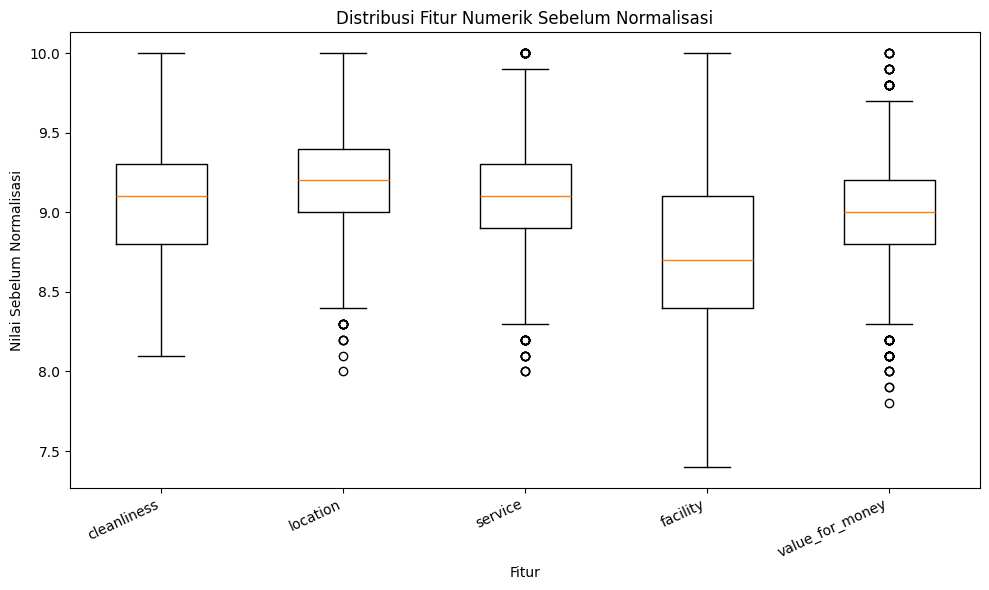

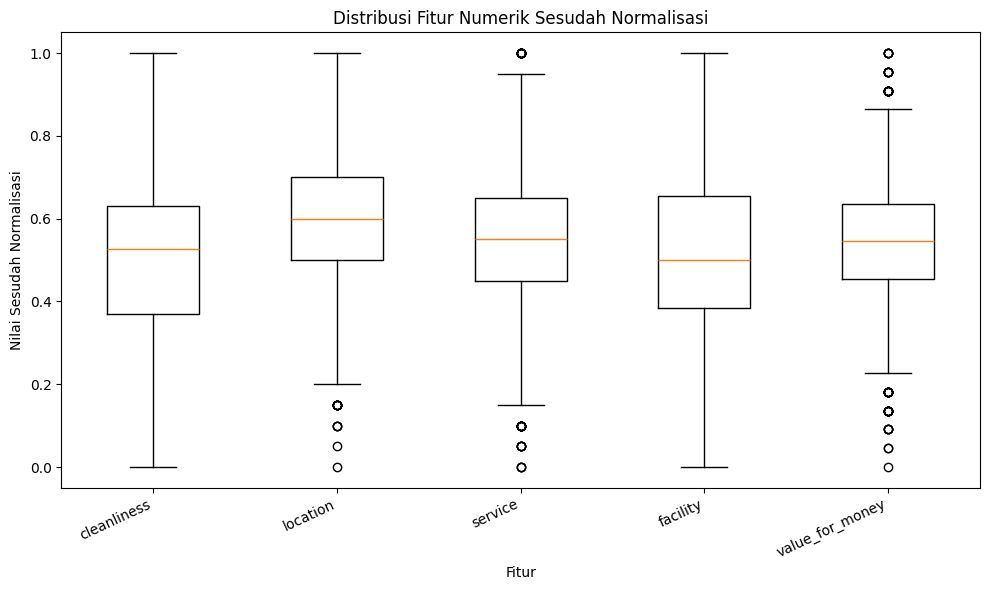

✅ Gambar berhasil disimpan:
   data/distribusi_sebelum_normalisasi.png
   data/distribusi_sesudah_normalisasi.png
   data/normalization_result.csv


In [ ]:
# Visualisasi perbandingan distribusi fitur sebelum dan sesudah normalisasi

import matplotlib.pyplot as plt

X_train_before_scaling = X.loc[X_train_reg.index, cols_to_scale].copy()
X_train_after_scaling = X_train_reg[cols_to_scale].copy()

# Buat tabel ringkasan hasil normalisasi
normalization_result = pd.DataFrame({
    'Fitur': cols_to_scale,
    'Min Sebelum': X_train_before_scaling.min().values,
    'Max Sebelum': X_train_before_scaling.max().values,
    'Min Sesudah': X_train_after_scaling.min().values,
    'Max Sesudah': X_train_after_scaling.max().values,
    'Rata-rata Sesudah': X_train_after_scaling.mean().values
})

# Pembulatan agar tabel lebih rapi untuk laporan
normalization_result[['Min Sebelum', 'Max Sebelum', 'Min Sesudah', 'Max Sesudah', 'Rata-rata Sesudah']] = \
    normalization_result[['Min Sebelum', 'Max Sebelum', 'Min Sesudah', 'Max Sesudah', 'Rata-rata Sesudah']].round(4)

print("📊 Hasil normalisasi fitur numerik pada data train:")
display(normalization_result)

# Simpan tabel hasil normalisasi ke CSV agar mudah dimasukkan ke laporan jika diperlukan
normalization_result.to_csv('data/normalization_result.csv', index=False)

# Plot distribusi sebelum normalisasi
plt.figure(figsize=(10, 6))
plt.boxplot(
    [X_train_before_scaling[col] for col in cols_to_scale],
    labels=cols_to_scale
)
plt.title('Distribusi Fitur Numerik Sebelum Normalisasi')
plt.xlabel('Fitur')
plt.ylabel('Nilai Sebelum Normalisasi')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('plots/distribusi_sebelum_normalisasi.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot distribusi sesudah normalisasi
plt.figure(figsize=(10, 6))
plt.boxplot(
    [X_train_after_scaling[col] for col in cols_to_scale],
    labels=cols_to_scale
)
plt.title('Distribusi Fitur Numerik Sesudah Normalisasi')
plt.xlabel('Fitur')
plt.ylabel('Nilai Sesudah Normalisasi')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('plots/distribusi_sesudah_normalisasi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gambar berhasil disimpan:")
print("   data/distribusi_sebelum_normalisasi.png")
print("   data/distribusi_sesudah_normalisasi.png")
print("   data/normalization_result.csv")


In [15]:
import pandas as pd
import joblib
from sklearn.impute import KNNImputer

# Load dataset mentah
df = pd.read_csv("data/hotel_reviews_dataset.csv")

# Kolom final untuk imputasi, tanpa overall_score
numeric_cols_for_impute = [
    "cleanliness",
    "location",
    "service",
    "facility",
    "value_for_money"
]

# Fit ulang KNN Imputer
imputer = KNNImputer(n_neighbors=5)
imputer.fit(df[numeric_cols_for_impute])

# Simpan ulang imputer final
joblib.dump(imputer, "models/knn_imputer.pkl")
joblib.dump(numeric_cols_for_impute, "models/numeric_cols_for_impute.pkl")

print("KNN Imputer berhasil disimpan ulang.")
print("Kolom yang dipakai:")
print(imputer.feature_names_in_)

KNN Imputer berhasil disimpan ulang.
Kolom yang dipakai:
['cleanliness' 'location' 'service' 'facility' 'value_for_money']
